# Chinese A-Share Pair Trading: Data Exploration

This notebook starts the pair-trading research project from the existing SQLite store at `data/prices.sqlite`.

Goals:

- verify the database and table structure
- understand coverage, date range, symbol availability, and data quality
- define a practical research universe for Chinese equities
- build a close-price and return panel
- screen candidate pairs using correlation plus a simple residual mean-reversion diagnostic

The environment currently has `pandas` and `numpy`, but not `matplotlib`, `scipy`, or `statsmodels`, so the first pass keeps dependencies minimal.

Initial inspection already confirmed:

- `daily_prices` contains 10,144,954 daily bars
- 5,524 distinct symbols are present
- 2,426 trading dates are present
- date coverage runs from `20160601` through `20260601`
- the conversion manifest contains 5,525 original CSV files and matching row totals
- `PRAGMA integrity_check` returned `ok` after the CSVs were removed

In [ ]:
from pathlib import Path
import sqlite3
import math

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")

DB_PATH = Path("data/prices.sqlite")
assert DB_PATH.exists(), f"Missing database: {DB_PATH.resolve()}"

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA query_only = ON")
DB_PATH.resolve()

WindowsPath('C:/Program Files/New folder/data/prices.sqlite')

## 1. Database Sanity Check

Start by confirming the database opens cleanly, then inspect the tables and indexes. The primary table is `daily_prices`; `csv_manifest` preserves the original source-file row counts and SHA-256 hashes from the CSV conversion.

In [2]:
integrity = conn.execute("PRAGMA integrity_check").fetchone()[0]
integrity

'ok'

In [3]:
schema = pd.read_sql_query(
    """
    SELECT type, name, tbl_name, sql
    FROM sqlite_master
    WHERE type IN ('table', 'index')
    ORDER BY type, name
    """,
    conn,
)
schema

,type,name,tbl_name,sql
0,index,idx_adj_factor_trade_date,adj_factor,CREATE INDEX idx_adj_factor_trade_date ON adj_...
1,index,idx_adj_factor_ts_trade,adj_factor,CREATE INDEX idx_adj_factor_ts_trade ON adj_fa...
2,index,idx_daily_prices_source_file,daily_prices,CREATE INDEX idx_daily_prices_source_file ON d...
3,index,idx_daily_prices_trade_date,daily_prices,CREATE INDEX idx_daily_prices_trade_date ON da...
4,index,idx_daily_prices_ts_trade,daily_prices,CREATE INDEX idx_daily_prices_ts_trade ON dail...
5,index,sqlite_autoindex_csv_manifest_1,csv_manifest,NaN
6,index,sqlite_autoindex_tushare_adj_fetch_status_1,tushare_adj_fetch_status,NaN
7,table,adj_factor,adj_factor,CREATE TABLE adj_factor (\n ts_code...
8,table,csv_manifest,csv_manifest,CREATE TABLE csv_manifest (\n sourc...
9,table,daily_prices,daily_prices,CREATE TABLE daily_prices (\n ts_co...


In [4]:
profile = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT ts_code) AS symbols,
        COUNT(DISTINCT trade_date) AS trading_dates,
        MIN(trade_date) AS first_trade_date,
        MAX(trade_date) AS last_trade_date
    FROM daily_prices
    """,
    conn,
)

manifest_profile = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS source_files,
        SUM(rows) AS manifest_rows,
        SUM(bytes) AS original_csv_bytes
    FROM csv_manifest
    """,
    conn,
)

display(profile)
display(manifest_profile)

,rows,symbols,trading_dates,first_trade_date,last_trade_date
0,10144954,5524,2426,20160601,20260601


,source_files,manifest_rows,original_csv_bytes
0,5525,10144954,801219368


## 2. Market Coverage

Pair trading is sensitive to missing data. A pair cannot be evaluated over a window if one leg has sparse or intermittent prices, so coverage is one of the first filters.

In [5]:
coverage_by_symbol = pd.read_sql_query(
    """
    SELECT
        ts_code,
        COUNT(*) AS bars,
        MIN(trade_date) AS first_date,
        MAX(trade_date) AS last_date,
        AVG(amount) AS avg_amount,
        AVG(vol) AS avg_vol
    FROM daily_prices
    GROUP BY ts_code
    ORDER BY bars DESC, ts_code
    """,
    conn,
)

coverage_by_symbol.head(10)

,ts_code,bars,first_date,last_date,avg_amount,avg_vol
0,000001.SZ,2426,20160601,20260601,1.37161e+06,1.05004e+06
1,000009.SZ,2426,20160601,20260601,"507,278","461,216"
2,000011.SZ,2426,20160601,20260601,"119,933","89,595.5"
3,000012.SZ,2426,20160601,20260601,"206,644","273,674"
4,000014.SZ,2426,20160601,20260601,"107,875","87,804.9"
5,000026.SZ,2426,20160601,20260601,"91,152.5","70,094.9"
6,000027.SZ,2426,20160601,20260601,"192,007","253,570"
7,000036.SZ,2426,20160601,20260601,"106,701","182,706"
8,000055.SZ,2426,20160601,20260601,"68,554.4","116,522"
9,000059.SZ,2426,20160601,20260601,"163,713","222,669"


In [6]:
coverage_summary = coverage_by_symbol[["bars", "avg_amount", "avg_vol"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
coverage_summary

,bars,avg_amount,avg_vol
count,"5,524","5,524","5,524"
mean,"1,836.52","212,621","140,061"
std,683.542,"332,568","227,045"
min,2,"8,739.67","3,282.95"
1%,79,"19,166.3","8,790.38"
5%,584.15,"38,948.8","14,113"
25%,"1,249.5","74,029.4","33,968.5"
50%,"2,238.5","123,702","72,844.6"
75%,"2,415","222,558","165,311"
95%,"2,426","643,333","447,162"


In [7]:
coverage_by_date = pd.read_sql_query(
    """
    SELECT trade_date, COUNT(*) AS listed_symbols
    FROM daily_prices
    GROUP BY trade_date
    ORDER BY trade_date
    """,
    conn,
)

display(coverage_by_date.head())
display(coverage_by_date.tail())
coverage_by_date["listed_symbols"].describe()

,trade_date,listed_symbols
0,20160601,2406
1,20160602,2399
2,20160603,2414
3,20160606,2415
4,20160607,2423


,trade_date,listed_symbols
2421,20260526,5504
2422,20260527,5506
2423,20260528,5506
2424,20260529,5506
2425,20260601,5508


count      2,426
mean    4,181.76
std      974.903
min        2,399
25%     3,345.25
50%      4,219.5
75%     5,220.75
max        5,508
Name: listed_symbols, dtype: float64

In [8]:
pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_price_rows,
        SUM(CASE WHEN a.adj_factor IS NULL THEN 1 ELSE 0 END) AS missing_adj_factor,
        SUM(CASE WHEN a.adj_factor IS NOT NULL THEN 1 ELSE 0 END) AS has_adj_factor
    FROM daily_prices d
    LEFT JOIN adj_factor a
        ON d.ts_code = a.ts_code
        AND d.trade_date = a.trade_date
    """, 
    conn
)

,total_price_rows,missing_adj_factor,has_adj_factor
0,10144954,9066,10135888


In [9]:
prices_missing_adj_factors = pd.read_sql_query(
    """
    SELECT d.ts_code, d.trade_date
    FROM daily_prices d
    LEFT JOIN adj_factor a
        ON d.ts_code = a.ts_code
        AND d.trade_date = a.trade_date
    WHERE a.adj_factor IS NULL
    ORDER BY d.ts_code, d.trade_date
    """, 
    conn
)
display(prices_missing_adj_factors.head(10))
display(prices_missing_adj_factors.tail(10))

,ts_code,trade_date
0,603607.SH,20201020
1,603607.SH,20201021
2,603607.SH,20201022
3,603607.SH,20201023
4,603607.SH,20201026
5,603607.SH,20201027
6,603607.SH,20201028
7,603607.SH,20201029
8,603607.SH,20201030
9,603607.SH,20201102


,ts_code,trade_date
9056,605158.SH,20210222
9057,605158.SH,20210223
9058,605158.SH,20210224
9059,605158.SH,20210225
9060,605158.SH,20210226
9061,605158.SH,20210301
9062,605158.SH,20210302
9063,605158.SH,20210303
9064,605158.SH,20210304
9065,605158.SH,20210305


In [10]:
companies_missing_adj_factors = pd.read_sql_query(
    """
    SELECT d.ts_code, SUM(CASE WHEN a.adj_factor IS NULL THEN 1 ELSE 0 END) AS missing_adj_factor_count
    FROM daily_prices d
    LEFT JOIN adj_factor a
        ON d.ts_code = a.ts_code
        AND d.trade_date = a.trade_date
    WHERE a.adj_factor IS NULL
    GROUP BY d.ts_code
    ORDER BY d.ts_code
    """,
    conn
)
display(companies_missing_adj_factors) # 104 companies missing between 1 to 100 adjusting factors

,ts_code,missing_adj_factor_count
0,603607.SH,93
1,603880.SH,93
2,603881.SH,93
3,603882.SH,93
4,603883.SH,93
...,...,...
99,605133.SH,8
100,605136.SH,93
101,605151.SH,53
102,605155.SH,41


## 3. Basic Data Quality

The SQLite primary key prevents duplicate `(ts_code, trade_date)` rows. The checks below focus on missing values, non-positive prices, OHLC inconsistencies, and suspicious return/price-change mismatches.

In [11]:
quality = pd.read_sql_query(
    """
    SELECT
        SUM(CASE WHEN close IS NULL OR close <= 0 THEN 1 ELSE 0 END) AS bad_close,
        SUM(CASE WHEN open IS NULL OR open <= 0 THEN 1 ELSE 0 END) AS bad_open,
        SUM(CASE WHEN high IS NULL OR high <= 0 THEN 1 ELSE 0 END) AS bad_high,
        SUM(CASE WHEN low IS NULL OR low <= 0 THEN 1 ELSE 0 END) AS bad_low,
        SUM(CASE WHEN high < low THEN 1 ELSE 0 END) AS high_below_low,
        SUM(CASE WHEN close > high OR close < low THEN 1 ELSE 0 END) AS close_outside_range,
        SUM(CASE WHEN open > high OR open < low THEN 1 ELSE 0 END) AS open_outside_range,
        SUM(CASE WHEN amount IS NULL OR amount < 0 THEN 1 ELSE 0 END) AS bad_amount,
        SUM(CASE WHEN vol IS NULL OR vol < 0 THEN 1 ELSE 0 END) AS bad_vol
    FROM daily_prices
    """,
    conn,
)
quality

,bad_close,bad_open,bad_high,bad_low,high_below_low,close_outside_range,open_outside_range,bad_amount,bad_vol
0,0,0,0,0,0,0,0,0,0


In [12]:
extreme_returns = pd.read_sql_query(
    """
    SELECT 
        d.ts_code,
        d.trade_date,
        d.close,
        d.pre_close,
        d.pct_chg,
        d.amount,
        a.adj_factor,
        d.close * a.adj_factor AS adj_close,
        d.pre_close * a.adj_factor AS adj_pre_close
    FROM daily_prices d
    LEFT JOIN adj_factor a
        ON d.ts_code = a.ts_code
        AND d.trade_date = a.trade_date
    WHERE ABS(d.pct_chg) >= 20 OR ABS(d.pct_chg) <= 1/20
    ORDER BY ABS(d.pct_chg) DESC
    LIMIT 30
    """,
    conn,
)
extreme_returns

,ts_code,trade_date,close,pre_close,pct_chg,amount,adj_factor,adj_close,adj_pre_close
0,920227.BJ,20220225,20.05,0.01,"200,400",20.05,938,"18,806.9",9.38
1,920427.BJ,20200204,10.96,0.01,"109,500",63.08,100,"1,096",1
2,920914.BJ,20160603,6.86,0.01,"68,500",144,1,6.86,0.01
3,920199.BJ,20220511,50,0.95,"5,163.16",5,3.7895,189.475,3.60002
4,920751.BJ,20191112,4.1,0.1,"4,000",4.1,11.5,47.15,1.15
5,920892.BJ,20200225,19.63,0.49,"3,906.12",39.27,7.7551,152.233,3.8
6,301025.SZ,20210719,31.66,1.55,"1,942.58","673,990",1,31.66,1.55
7,603395.SH,20241126,160.99,7.98,"1,917.42",3.09568e+06,1,160.99,7.98
8,301487.SZ,20230809,98.02,5.32,"1,742.48",1.23243e+06,1,98.02,5.32
9,001279.SZ,20241011,178.01,9.68,"1,738.95",4.70853e+06,1,178.01,9.68


## 4. Define a Research Universe

For the first pass, use a recent, liquid, well-covered universe. This does not yet handle industries, ST flags, suspensions, index membership, or corporate actions beyond the supplied close prices. Those are important follow-up data additions for live-grade research.

Initial filters:

- has data through the latest available date
- at least 700 bars in the selected research window
- average traded amount above a configurable threshold
- optional exchange filter can be added later from `ts_code` suffixes

Tushare Unit Conversions:

- vol: 1 = 100 (total shares traded)
- amount: 1 = 1000 yuan (total volume traded)
- total_mv: 1 = 10000 yuan (market cap)
- total_share: 1 = 10000 (total shares outstanding)
- pct_chg: 1 = 0.01 (percentage change in price, measured in %)



In [ ]:
start_date = 20160101
end_date = 20220101 # formation date should be separate from backtesting date range to avoid look-ahead bias in pair selection. We can use 2023-2026 data for backtesting. 
min_bars = 700  # available universe should have at least 700 trading days (out of ~750 total) to ensure sufficient historical data for backtesting.
min_avg_amount = 50_000  # Tushare daily amount is typically in thousand RMB; this is a filter to exclude very illiquid stocks that may not be suitable for trading strategies, but confirm before production sizing.

universe = pd.read_sql_query(
    """
    SELECT
        ts_code,
        COUNT(*) AS bars,
        MIN(trade_date) AS first_date,
        MAX(trade_date) AS last_date,
        AVG(amount) AS avg_amount,
        AVG(vol) AS avg_vol
    FROM daily_prices
    WHERE trade_date >= ?
    GROUP BY ts_code
    HAVING bars >= ?
       AND last_date = ?
       AND avg_amount >= ?
    ORDER BY avg_amount DESC
    """,
    conn,
    params=(start_date, min_bars, end_date, min_avg_amount),
)

print(f"Universe size: {len(universe):,}")
universe.head(20)

Universe size: 4,574


,ts_code,bars,first_date,last_date,avg_amount,avg_vol
0,300750.SZ,1308,20210104,20260601,6.93354e+06,"211,674"
1,300059.SZ,1308,20210104,20260601,6.86451e+06,2.97403e+06
2,600519.SH,1308,20210104,20260601,5.73877e+06,"34,075.1"
3,300308.SZ,1308,20210104,20260601,5.00955e+06,"254,619"
4,002594.SZ,1308,20210104,20260601,4.69947e+06,"226,770"
5,300502.SZ,1308,20210104,20260601,4.39405e+06,"306,543"
6,300274.SZ,1308,20210104,20260601,4.28179e+06,"375,629"
7,601012.SH,1308,20210104,20260601,3.8285e+06,1.069e+06
8,002475.SZ,1308,20210104,20260601,3.72768e+06,"886,196"
9,601899.SH,1308,20210104,20260601,3.61402e+06,2.22537e+06


## 5. Build Price And Return Panels

A full 5,000-symbol correlation matrix is unnecessarily large for a starter pass. The cell below uses the most liquid names in the filtered universe. Increase `max_symbols` once the workflow is stable.

In [16]:
max_symbols = 350
selected_symbols = universe.head(max_symbols)["ts_code"].tolist()

placeholders = ",".join("?" for _ in selected_symbols)
prices_long = pd.read_sql_query(
    f"""
    SELECT ts_code, trade_date, close, amount
    FROM daily_prices
    WHERE trade_date >= ?
      AND ts_code IN ({placeholders})
    ORDER BY trade_date, ts_code
    """,
    conn,
    params=[start_date, *selected_symbols],
)
adj_factors_long = pd.read_sql_query(
    f"""
    SELECT ts_code, trade_date, adj_factor
    FROM adj_factor
    WHERE trade_date >= ?
      AND ts_code IN ({placeholders})
    ORDER BY trade_date, ts_code
    """,
    conn,
    params=[start_date, *selected_symbols],
)

prices_long["date"] = pd.to_datetime(prices_long["trade_date"].astype(str), format="%Y%m%d")
adj_factors_long["date"] = pd.to_datetime(adj_factors_long["trade_date"].astype(str), format="%Y%m%d")
close_panel = prices_long.pivot(index="date", columns="ts_code", values="close").sort_index()
adj_factors_panel = adj_factors_long.pivot(index="date", columns="ts_code", values="adj_factor").sort_index()
close_panel = close_panel * adj_factors_panel
amount_panel = prices_long.pivot(index="date", columns="ts_code", values="amount").sort_index()

returns = close_panel.pct_change(fill_method=None)
log_prices = np.log(close_panel)

display(close_panel.shape)
display(close_panel.tail())

(1308, 350)

ts_code,000001.SZ,000002.SZ,000021.SZ,000034.SZ,000063.SZ,000066.SZ,000100.SZ,000155.SZ,000158.SZ,000333.SZ,000338.SZ,000426.SZ,000519.SZ,000547.SZ,000568.SZ,000617.SZ,000625.SZ,000630.SZ,000651.SZ,000657.SZ,000661.SZ,000681.SZ,000723.SZ,000725.SZ,000762.SZ,000768.SZ,000776.SZ,000792.SZ,000799.SZ,000807.SZ,000831.SZ,000858.SZ,000933.SZ,000938.SZ,000960.SZ,000963.SZ,000977.SZ,000981.SZ,000983.SZ,000988.SZ,...,601857.SH,601868.SH,601881.SH,601888.SH,601899.SH,601919.SH,601933.SH,601939.SH,601985.SH,601988.SH,601995.SH,603000.SH,603005.SH,603019.SH,603083.SH,603259.SH,603501.SH,603659.SH,603799.SH,603881.SH,603893.SH,603986.SH,603993.SH,605117.SH,688008.SH,688012.SH,688041.SH,688072.SH,688110.SH,688111.SH,688223.SH,688256.SH,688313.SH,688343.SH,688498.SH,688521.SH,688525.SH,688599.SH,688629.SH,688981.SH
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-26,"1,452.11",615.977,630.135,126.547,607.929,212.454,17.511,22.8953,49.7707,448.71,817.138,746.883,148.073,237.804,"3,453.1",63.3279,128.95,207.446,"8,957.68",391.302,623.456,101.654,28.4867,31.3149,172.486,192.235,123.418,239.714,86.9785,234.126,206.201,"1,704.97",487.447,206.343,149.997,393.75,449.551,34.1518,78.4222,"1,739.56",...,19.6973,3.12771,14.9217,131.048,71.6134,34.8508,33.0084,25.6966,10.7573,15.2714,35.4079,78.1258,126.88,385.14,461.32,264.97,145.963,133.252,150.02,115.673,202.146,"2,976.35",75.1147,897.492,280.622,466.152,342.354,"1,648.58",156.371,246.32,6.4584,"2,104.02",172.551,77.01,"2,124.16",266.15,307.73,17.6364,147.144,149.18
2026-05-27,"1,448.07",605.074,648.265,117.511,595.614,202.107,17.6239,22.5881,46.7892,451.417,808.932,703.774,145.273,226.48,"3,498.74",61.7327,125.842,196.208,"8,895.48",374.769,607.822,99.9795,28.1459,31.0436,168.008,187.24,121.613,231.239,92.195,220.458,198.553,"1,715.81",463.521,200.06,140.438,396.312,430.981,32.8315,78.7808,"1,632.93",...,19.4098,3.05399,14.8269,130.352,68.8273,34.3242,34.3837,25.4723,10.7204,15.1164,35.0785,76.9923,121,371.503,424.313,261.204,144.435,134.673,144.856,113.178,208.412,"2,908.25",72.2008,946.519,273.624,457.644,317.899,"1,466.13",149.184,240.068,6.32385,"1,998.21",156.333,74.26,"2,293.3",252.45,316.99,17.3062,144.809,146.22
2026-05-28,"1,434.62",601.44,628.661,119.282,655.141,205.96,17.285,22.6851,46.7597,445.325,827.924,677.258,156.152,232.783,"3,386.15",61.972,122.424,205.016,"8,727.29",398.702,585.292,100.182,29.1,30.8265,167.566,186.809,119.551,229.913,89.6298,212.553,208.415,"1,666.72",450.195,206.486,139.324,388.626,443.606,33.0075,80.3349,"1,691.66",...,19.4098,3.05399,14.3765,126.945,66.8465,33.9173,32.825,25.1483,10.8679,15.013,34.3992,76.5563,128.286,372.565,457.043,256.546,140.225,132.047,144.339,115.797,199.369,"2,731.9",70.2575,941.957,268.966,455.703,315.46,"1,478.46",148.982,239.926,6.4377,"2,075",165.189,73.4,"2,330.39",264.95,323.62,17.2956,152.504,153.7
2026-05-29,"1,470.95",645.049,586.505,117.329,628.114,195.942,16.1176,23.0408,45.2542,456.043,828.628,679.14,157.352,216.865,"3,462.99",62.2112,123.046,209.572,"9,024.5",393.094,589.862,104.496,29.509,27.733,163.475,187.326,121.742,226.744,98.5971,210.484,196.42,"1,736.26",451.908,204.487,134.76,391.323,431.715,31.5992,81.1717,"1,551.63",...,19.5356,3.04346,14.5543,138.118,66.2587,33.8455,33.9253,24.8243,11.1138,15.1422,34.78,76.4255,115.458,360.193,467.533,262.697,130.73,131.874,141.499,110.402,181.327,"2,641.46",69.1737,894.244,260.742,446.431,294.929,"1,380.38",143.297,242.077,6.0651,"1,953.47",164.089,68.55,"2,311.23",246.84,327.37,16.4223,142.224,139.91
2026-06-01,"1,479.03",630.513,536.978,120.735,600.403,203.428,16.5695,23.6067,46.9368,460.837,790.174,678.969,154.232,214.728,"3,438.64",62.8493,125.376,207.142,"9,006.07",365.231,586.495,114.951,30.1904,29.0898,162.259,189.824,122.451,223.87,97.6487,213.587,196.621,"1,705.99",470.575,198.775,141.085,391.862,428.442,31.5992,87.2686,"1,461.25",...,19.4457,3.06452,14.6372,136.032,65.7146,35.5689,33.6502,25.1234,11.2859,15.3231,34.8418,78.38

In [23]:
panel_quality = pd.DataFrame({
    "close_missing_pct": close_panel.isna().mean().mul(100),
    "return_missing_pct": returns.isna().mean().mul(100),
    "avg_amount": amount_panel.mean(),
    "realized_vol_daily": returns.std(skipna=True),
}).sort_values("close_missing_pct")

panel_quality.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,close_missing_pct,return_missing_pct,avg_amount,realized_vol_daily
count,350,350,350,350
mean,1.73853,1.83137,1.29201e+06,0.0299576
std,6.78534,6.78528,"886,227",0.00771097
min,0,0.0764526,"652,645",0.0100927
1%,0,0.0764526,"656,072",0.0109713
5%,0,0.0764526,"677,356",0.0173778
25%,0,0.0764526,"770,408",0.0249424
50%,0,0.0764526,"968,737",0.0301016
75%,0,0.0764526,1.45119e+06,0.0345921
95%,12.8249,12.9014,3.15417e+06,0.0421023


## 6. Correlation Screen

Correlation alone is not a pair-trading signal, but it is a useful first-stage reduction. Candidate pairs should also have residuals that look mean-reverting and tradeable after costs.

In [31]:
clean_returns = returns.dropna(axis=1, thresh=int(0.9 * len(returns))).dropna(how="all")
corr = clean_returns.corr(min_periods=500)

corr.index.name = "leg_1"
corr.columns.name = "leg_2"
corr_values = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().rename("return_corr")
top_corr_pairs = corr_values.sort_values(ascending=False).head(500)

top_corr_pairs.head(50)

leg_1      leg_2    
000568.SZ  000858.SZ   0.864004
601398.SH  601939.SH    0.84306
600489.SH  600547.SH   0.841366
000858.SZ  600519.SH   0.833368
000630.SZ  600362.SH   0.822601
                         ...   
600118.SH  601698.SH   0.755982
000799.SZ  600702.SH   0.755893
300347.SZ  300759.SZ   0.755849
601328.SH  601939.SH   0.754072
000776.SZ  600030.SH   0.753826
Name: return_corr, Length: 50, dtype: float64

## 7. Fundamental Screen

High Correlation alone doesn't justify relationships between two stocks. They also have to be fundamentally similar, so that their share price is influenced by similar factors. To verfiy this, we will use Barra's factor model to decompose a stock by its exposure to macroeconomic factors, and then compare cosine similarity of the exposuer vectors to verify if two stocks are similar in terms of exposure (operationally). In addition, we will use Mahalanobis Distance on the firm's financial ratios to ensure that the two companies are also similar financially. As a final check, we will make sure the two companies operate in related industries. 

Refer to barra_macro.ipynb for this screen


## 8. Residual Mean-Reversion Diagnostics

This section estimates `log(P1) = alpha + beta * log(P2) + residual`, then tests whether the residual behaves like a mean-reverting process. Without `statsmodels`, we compute a compact diagnostic set rather than formal p-values:

- hedge beta from OLS
- spread volatility
- AR(1) coefficient of spread changes
- half-life estimate
- ADF-style t-statistic for `delta_spread ~ spread_lag`

More negative ADF-style t-stats and reasonable half-lives are better. Treat this as a ranking tool, not a final statistical proof.

In [43]:
def residual_diagnostics(y: pd.Series, x: pd.Series) -> dict | None:
    pair = pd.concat([y, x], axis=1).dropna()
    if len(pair) < 500:
        return None

    yv = pair.iloc[:, 0].to_numpy(dtype=float)
    xv = pair.iloc[:, 1].to_numpy(dtype=float)
    x_design = np.column_stack([np.ones(len(xv)), xv])
    alpha, beta = np.linalg.lstsq(x_design, yv, rcond=None)[0]
    spread = yv - (alpha + beta * xv)
    spread_std = spread.std(ddof=1)
    if not np.isfinite(spread_std) or spread_std == 0:
        return None

    spread_lag = spread[:-1]
    delta = np.diff(spread)
    adf_design = np.column_stack([np.ones(len(spread_lag)), spread_lag])
    coef = np.linalg.lstsq(adf_design, delta, rcond=None)[0]
    resid = delta - adf_design @ coef
    dof = len(delta) - adf_design.shape[1]
    if dof <= 0:
        return None
    sigma2 = (resid @ resid) / dof
    xtx_inv = np.linalg.inv(adf_design.T @ adf_design)
    se_gamma = math.sqrt(sigma2 * xtx_inv[1, 1])
    gamma = coef[1]
    adf_t = gamma / se_gamma if se_gamma else np.nan

    phi = 1 + gamma
    half_life = -np.log(2) / np.log(phi) if 0 < phi < 1 else np.nan
    z_last = (spread[-1] - spread.mean()) / spread_std

    return {
        "n_obs": len(pair),
        "alpha": alpha,
        "beta": beta,
        "spread_std": spread_std,
        "adf_t_approx": adf_t,
        "phi": phi,
        "half_life_days": half_life,
        "last_zscore": z_last,
    }


candidate_rows = []
for row in top_corr_pairs.head(200).items():
    leg_1, leg_2 = row[0]
    diag = residual_diagnostics(log_prices.loc[:, leg_1], log_prices.loc[:, leg_2])
    if diag is None:
        continue
    candidate_rows.append({"leg_1": leg_1, "leg_2": leg_2, "return_corr": row[1], **diag})

candidates = pd.DataFrame(candidate_rows)
candidates = candidates.sort_values(["adf_t_approx", "return_corr"], ascending=[True, False])
candidates.head(30)

,leg_1,leg_2,return_corr,n_obs,alpha,beta,spread_std,adf_t_approx,phi,half_life_days,last_zscore
177,600010.SH,600111.SH,0.664266,1308,-0.991001,0.59871,0.075869,-4.59308,0.967282,20.8368,-1.75341
61,600030.SH,601211.SH,0.746166,1283,1.63021,1.11323,0.0571087,-4.56848,0.968819,21.8814,1.80528
194,300418.SZ,300624.SZ,0.656122,1308,0.469614,0.913286,0.132457,-4.46574,0.969852,22.6429,1.52485
138,000762.SZ,600338.SH,0.68721,1308,2.24559,0.820937,0.121279,-4.44135,0.974542,26.8787,-0.429683
124,000977.SZ,603019.SH,0.691891,1298,1.88568,0.704572,0.0979002,-4.3437,0.972404,24.7695,0.477547
163,300118.SZ,688599.SH,0.673534,1308,2.01005,0.608843,0.168973,-4.24304,0.980017,34.3396,1.02125
173,601788.SH,601881.SH,0.667317,1308,1.94526,0.406619,0.0732801,-4.18379,0.973474,25.7829,-1.49859
101,002407.SZ,002709.SZ,0.706603,1308,-0.332982,0.87996,0.117304,-4.08249,0.977038,29.8387,1.45323
196,300015.SZ,300896.SZ,0.654842,1308,1.29405,0.8824,0.139665,-3.97394,0.982261,38.7269,1.01692
36,000768.SZ,600893.SH,0.766735,1308,2.41409,0.603766,0.0735338,-3.78341,0.977963,31.1065,-2.01567


In [44]:
tradable_candidates = candidates[
    candidates["half_life_days"].between(2, 60)
    & candidates["adf_t_approx"].lt(-3)
    & candidates["return_corr"].gt(0.6)
].copy()

tradable_candidates.head(30)

,leg_1,leg_2,return_corr,n_obs,alpha,beta,spread_std,adf_t_approx,phi,half_life_days,last_zscore
177,600010.SH,600111.SH,0.664266,1308,-0.991001,0.59871,0.075869,-4.59308,0.967282,20.8368,-1.75341
61,600030.SH,601211.SH,0.746166,1283,1.63021,1.11323,0.0571087,-4.56848,0.968819,21.8814,1.80528
194,300418.SZ,300624.SZ,0.656122,1308,0.469614,0.913286,0.132457,-4.46574,0.969852,22.6429,1.52485
138,000762.SZ,600338.SH,0.68721,1308,2.24559,0.820937,0.121279,-4.44135,0.974542,26.8787,-0.429683
124,000977.SZ,603019.SH,0.691891,1298,1.88568,0.704572,0.0979002,-4.3437,0.972404,24.7695,0.477547
163,300118.SZ,688599.SH,0.673534,1308,2.01005,0.608843,0.168973,-4.24304,0.980017,34.3396,1.02125
173,601788.SH,601881.SH,0.667317,1308,1.94526,0.406619,0.0732801,-4.18379,0.973474,25.7829,-1.49859
101,002407.SZ,002709.SZ,0.706603,1308,-0.332982,0.87996,0.117304,-4.08249,0.977038,29.8387,1.45323
196,300015.SZ,300896.SZ,0.654842,1308,1.29405,0.8824,0.139665,-3.97394,0.982261,38.7269,1.01692
36,000768.SZ,600893.SH,0.766735,1308,2.41409,0.603766,0.0735338,-3.78341,0.977963,31.1065,-2.01567


## 9. Inspect One Candidate Spread

Pick the top candidate and calculate its spread and z-score series. If plotting libraries are installed later, the final line will show a quick chart.

Inspecting 600010.SH vs 600111.SH; beta=0.5987


,value
leg_1,600010.SH
leg_2,600111.SH
return_corr,0.664266
n_obs,1308
alpha,-0.991001
beta,0.59871
spread_std,0.075869
adf_t_approx,-4.59308
phi,0.967282
half_life_days,20.8368


,spread,zscore
date,,
2026-04-30,-0.0641945,-0.846123
2026-05-06,-0.0480687,-0.633574
2026-05-07,-0.0529173,-0.697481
2026-05-08,-0.0575967,-0.759159
2026-05-11,-0.0516283,-0.680492
2026-05-12,-0.0541971,-0.71435
2026-05-13,-0.0620482,-0.817833
2026-05-14,-0.0742201,-0.978266
2026-05-15,-0.091182,-1.20183


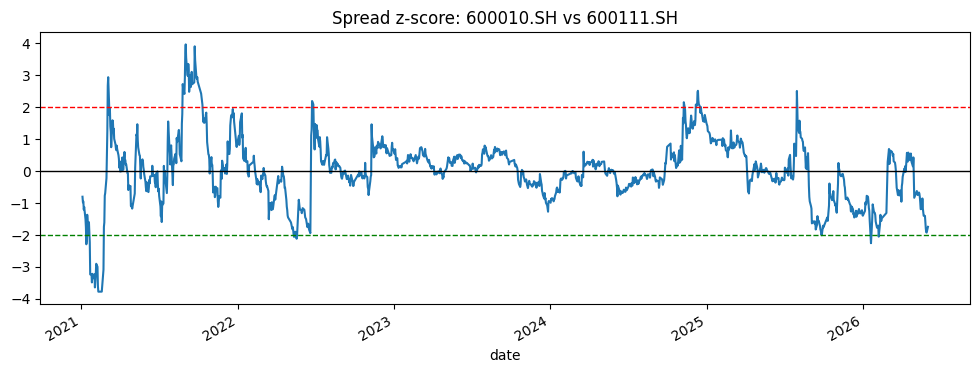

In [46]:
if tradable_candidates.empty:
    pair_to_inspect = candidates.iloc[0]
else:
    pair_to_inspect = tradable_candidates.iloc[0]

leg_1, leg_2 = pair_to_inspect["leg_1"], pair_to_inspect["leg_2"]
alpha, beta = pair_to_inspect["alpha"], pair_to_inspect["beta"]

spread = log_prices[leg_1] - (alpha + beta * log_prices[leg_2])
spread_z = (spread - spread.mean()) / spread.std(ddof=1)

print(f"Inspecting {leg_1} vs {leg_2}; beta={beta:.4f}")
display(pair_to_inspect.to_frame("value"))
display(pd.DataFrame({"spread": spread, "zscore": spread_z}).tail(20))


spread_z.plot(figsize=(12, 4), title=f"Spread z-score: {leg_1} vs {leg_2}")
plt.axhline(2, color="red", linestyle="--", linewidth=1)
plt.axhline(-2, color="green", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.show()

## 9. Research Notes And Next Steps

Immediate next steps for making this a serious Chinese-market pair-trading project:

- add stock metadata from Tushare: industry, listing date, delisting status, ST flags, exchange, market board
- use adjusted prices (`adj_factor`) instead of raw closes before final testing
- constrain pair search by industry or fundamental similarity before statistical screening
- split research into formation and trading windows to avoid look-ahead bias
- model A-share frictions: T+1 selling rule, limit-up/limit-down days, suspensions, borrow/shorting constraints, fees, stamp duty, and slippage
- replace approximate residual diagnostics with formal Engle-Granger / Johansen tests once `statsmodels` is installed
- create a vectorized backtest with explicit entry, exit, stop, rebalance, and capital-allocation rules